In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/mlran-dataset/MLRan_X_test_RFE.csv
/kaggle/input/mlran-dataset/mlran_dataset_metadata.csv
/kaggle/input/mlran-dataset/MLRan_X_train_RFE.csv
/kaggle/input/mlran-dataset/MLRan_labels.csv
/kaggle/input/mlran-dataset/type_test_sampleids.csv
/kaggle/input/mlran-dataset/type_train_sampleids.csv
/kaggle/input/mlran-dataset/RFE_selected_feature_names_dic.json


In [2]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/57.1 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.8/930.8 kB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 68.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 104.6 MB/s eta 0:00:00



PART 1: TRAINING AND VALIDATING THE MODEL

LOADING MLRAN DATA
Loaded data shape: (3905, 487)
Features shape: (3905, 483)
Labels shape: (3905,)
Label distribution: Benign=2040, Ransomware=1865
Subsampled to 200 samples
New label distribution: Benign=104, Ransomware=96

Final dataset for validation:
  Training: 160 samples
  Testing: 40 samples

--- Training Quantum SVM (QSVM) ---

Training MLRAN QSVM...
  Original feature count: 483
  Target qubits / components: 5
  Feature map: ZZ, Reps: 2, Entanglement: linear
  Explained variance by 5 components: 0.38
Computing kernel matrix (160x160)...
Kernel matrix computation complete.

Training complete!

Evaluating Quantum SVM...

VALIDATION RESULTS (Quantum SVM)
Accuracy: 0.7250
Prediction time: 142.35 seconds

Classification Report:
              precision    recall  f1-score   support

      Benign     0.7500    0.7143    0.7317        21
  Ransomware     0.7000    0.7368    0.7179        19

    accuracy                         0.7250     

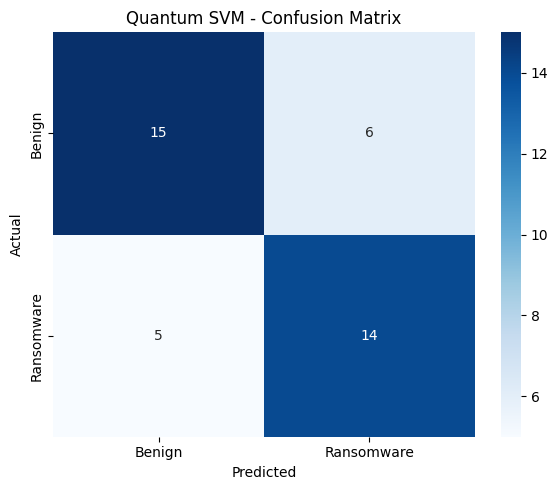


PART 2: MAKING FINAL PREDICTIONS ON THE SEPARATE TEST FILE
Loading final test data from /kaggle/input/mlran-dataset/MLRan_X_test_RFE.csv...
Predicting with the trained Quantum SVM...

Predictions complete!
Showing first 10 predictions (0 = Benign, 1 = Ransomware):
   sample_id  predicted_sample_type
0      11027                      0
1      11030                      1
2      11033                      0
3      11035                      0
4      11036                      1
5      11037                      0
6      11039                      0
7      11040                      0
8      11043                      0
9      11044                      0

Full predictions saved to 'submission_predictions.csv'


In [3]:
import numpy as np
import pandas as pd
import pennylane as qml
import torch
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import warnings

warnings.filterwarnings('ignore')

# =====================================================
# QSVM Implementation for MLRAN Binary Classification
# =====================================================

class MLRANQuantumSVM:
    """
    Quantum SVM adapted for the high-dimensional MLRAN dataset.
    Uses PCA for dimensionality reduction before quantum feature encoding.
    """
    
    def __init__(self, n_qubits=5, feature_map='ZZ', reps=2, entanglement='linear'):
        """
        Initialize QSVM for MLRAN data.
        
        Args:
            n_qubits: Number of qubits, which is also the number of principal components to use.
            feature_map: Type of quantum feature map ('ZZ' or 'Pauli').
            reps: Number of circuit repetitions.
            entanglement: Entanglement pattern ('linear' or 'full').
        """
        self.n_qubits = n_qubits
        self.feature_map = feature_map
        self.reps = reps
        self.entanglement = entanglement
        
        # Quantum device
        self.dev = qml.device("default.qubit", wires=n_qubits)
        
        # Will store the classifiers and transformers
        self.classifier = None
        self.X_train_final = None
        self.standard_scaler = None
        self.pca = None
        self.min_max_scaler = None

    def _apply_feature_map(self, x, wires):
        """Apply the selected quantum feature map."""
        if self.feature_map == 'ZZ':
            for rep in range(self.reps):
                for wire in wires:
                    qml.Hadamard(wires=wire)
                for i, wire in enumerate(wires):
                    qml.RZ(2.0 * x[i], wires=wire)
                if self.entanglement == 'linear':
                    for i in range(len(wires) - 1):
                        phi = (np.pi - x[i]) * (np.pi - x[i+1])
                        qml.CNOT(wires=[wires[i], wires[i + 1]])
                        qml.RZ(2 * phi, wires=wires[i + 1])
                        qml.CNOT(wires=[wires[i], wires[i + 1]])
                elif self.entanglement == 'full':
                    for i in range(len(wires)):
                        for j in range(i + 1, len(wires)):
                            phi = (np.pi - x[i]) * (np.pi - x[j])
                            qml.CNOT(wires=[wires[i], wires[j]])
                            qml.RZ(2 * phi, wires=wires[j])
                            qml.CNOT(wires=[wires[i], wires[j]])
        
        elif self.feature_map == 'Pauli':
            for rep in range(self.reps):
                for i, wire in enumerate(wires):
                    qml.RY(x[i] * np.pi, wires=wire)
                    qml.RZ(x[i] * np.pi, wires=wire)
                if rep < self.reps - 1:
                    if self.entanglement == 'linear':
                        for i in range(len(wires) - 1):
                            qml.CNOT(wires=[wires[i], wires[i + 1]])
                    elif self.entanglement == 'full':
                         for i in range(len(wires)):
                            for j in range(i + 1, len(wires)):
                                qml.CNOT(wires=[i, j])

    def compute_kernel(self, x1, x2):
        """Compute quantum kernel between two data points."""
        @qml.qnode(self.dev, interface='torch')
        def kernel_circuit():
            self._apply_feature_map(x1, range(self.n_qubits))
            qml.adjoint(self._apply_feature_map)(x2, range(self.n_qubits))
            return qml.probs(wires=range(self.n_qubits))
        
        return kernel_circuit()[0].numpy()

    def compute_kernel_matrix(self, X1, X2=None, verbose=True):
        """Compute kernel matrix with progress tracking."""
        if X2 is None:
            X2 = X1
            symmetric = True
        else:
            symmetric = False
        
        n1, n2 = len(X1), len(X2)
        K = np.zeros((n1, n2))
        
        total_computations = n1 * n2 if not symmetric else n1 * (n1 + 1) // 2
        
        if verbose:
            print(f"Computing kernel matrix ({n1}x{n2})...")
        
        # Parallel computation can speed this up if you have many cores
        for i in range(n1):
            for j in range(i if symmetric else 0, n2):
                K[i, j] = self.compute_kernel(X1[i], X2[j])
                if symmetric:
                    K[j, i] = K[i, j]
        
        if verbose:
            print("Kernel matrix computation complete.")
        return K

    def fit(self, X, y, C=1.0):
        """
        Train QSVM on MLRAN data. Includes scaling, PCA, and quantum kernel computation.
        
        Args:
            X: Training features (high-dimensional)
            y: Training labels (0 for benign, 1 for ransomware)
            C: SVM regularization parameter
        """
        print("\nTraining MLRAN QSVM...")
        print(f"  Original feature count: {X.shape[1]}")
        print(f"  Target qubits / components: {self.n_qubits}")
        print(f"  Feature map: {self.feature_map}, Reps: {self.reps}, Entanglement: {self.entanglement}")
        
        # Step 1: Standard Scaling (important for PCA)
        self.standard_scaler = StandardScaler()
        X_scaled = self.standard_scaler.fit_transform(X)
        
        # Step 2: PCA for dimensionality reduction
        self.pca = PCA(n_components=self.n_qubits)
        X_pca = self.pca.fit_transform(X_scaled)
        print(f"  Explained variance by {self.n_qubits} components: {np.sum(self.pca.explained_variance_ratio_):.2f}")
        
        # Step 3: Scale features to [-1, 1] for quantum circuits
        self.min_max_scaler = MinMaxScaler(feature_range=(-1, 1))
        self.X_train_final = self.min_max_scaler.fit_transform(X_pca)
        
        # Step 4: Compute the quantum kernel matrix
        K_train = self.compute_kernel_matrix(self.X_train_final)
        
        # Step 5: Train SVM with the precomputed quantum kernel
        self.classifier = SVC(kernel='precomputed', C=C, probability=True)
        self.classifier.fit(K_train, y)
        
        print("\nTraining complete!")
        return self

    def predict(self, X):
        """Make predictions on new MLRAN data."""
        # Apply the same transformations as in fit()
        X_scaled = self.standard_scaler.transform(X)
        X_pca = self.pca.transform(X_scaled)
        X_final = self.min_max_scaler.transform(X_pca)
        
        # Compute the test kernel matrix between new data and training data
        K_test = self.compute_kernel_matrix(X_final, self.X_train_final, verbose=False)
        
        return self.classifier.predict(K_test)

    def score(self, X, y):
        """Calculate accuracy score."""
        y_pred = self.predict(X)
        return accuracy_score(y, y_pred)

# =====================================================
# Data Loading and Evaluation
# =====================================================

def load_mlran_data(file_path, test_size=0.2, subsample=None):
    """
    Load and prepare MLRAN data from a CSV file.
    
    Args:
        file_path: Path to the train.csv file.
        test_size: Fraction of data for the test set.
        subsample: Number of samples to use for faster testing (None for all).
    """
    print("\n" + "="*50)
    print("LOADING MLRAN DATA")
    print("="*50)
    
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")
    
    df = pd.read_csv(file_path)
    print(f"Loaded data shape: {df.shape}")
    
    # Features are all columns after the first four
    feature_columns = df.columns[4:]
    X = df[feature_columns].values
    
    # Target is the 'sample_type' column (0: benign, 1: ransomware)
    y = df['sample_type'].values
    
    print(f"Features shape: {X.shape}")
    print(f"Labels shape: {y.shape}")
    print(f"Label distribution: Benign={np.sum(y==0)}, Ransomware={np.sum(y==1)}")
    
    # Subsample if requested for quicker runs
    if subsample and subsample < len(X):
        # Use stratified sampling to maintain class distribution
        _, X, _, y = train_test_split(X, y, test_size=subsample/len(X), random_state=42, stratify=y)
        print(f"Subsampled to {len(X)} samples")
        print(f"New label distribution: Benign={np.sum(y==0)}, Ransomware={np.sum(y==1)}")
    
    # Split into train/test sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )
    
    print(f"\nFinal dataset for validation:")
    print(f"  Training: {len(X_train)} samples")
    print(f"  Testing: {len(X_test)} samples")
    
    return X_train, X_test, y_train, y_test

def evaluate_mlran_qsvm(model, X_test, y_test, model_name="QSVM"):
    """Evaluate QSVM on the MLRAN test data."""
    print(f"\nEvaluating {model_name}...")
    
    start_time = time.time()
    y_pred = model.predict(X_test)
    pred_time = time.time() - start_time
    
    accuracy = accuracy_score(y_test, y_pred)
    
    print("\n" + "="*50)
    print(f"VALIDATION RESULTS ({model_name})")
    print("="*50)
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Prediction time: {pred_time:.2f} seconds")
    
    target_names = ['Benign', 'Ransomware']
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=target_names, digits=4))
    
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names)
    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()
    
    return accuracy, pred_time

# =====================================================
# Main Execution
# =====================================================

if __name__ == "__main__":
    # --- IMPORTANT: UPDATE FILE PATHS HERE ---
    train_csv_file = "/kaggle/input/mlran-dataset/MLRan_X_train_RFE.csv"
    test_csv_file = "/kaggle/input/mlran-dataset/MLRan_X_test_RFE.csv"
    # -----------------------------------------
    
    if not os.path.exists(train_csv_file):
        print(f"ERROR: Training file not found at '{train_csv_file}'")
        print("Please update the 'train_csv_file' variable with the correct path.")
        exit(1)

    # =======================================================
    # PART 1: MODEL TRAINING AND VALIDATION
    # =======================================================
    print("\n" + "="*60)
    print("PART 1: TRAINING AND VALIDATING THE MODEL")
    print("="*60)
    
    # Load data from train.csv and split it for validation
    # NOTE: Using a small subsample for a quick demonstration.
    # For a full run, set subsample=None, but be aware it will be VERY slow.
    X_train, X_test_val, y_train, y_test_val = load_mlran_data(
        train_csv_file,
        test_size=0.2,
        subsample=200  # Use a small number like 200 for a test. Use None for the full dataset.
    )
    
    # 1. Train and evaluate the Quantum SVM
    print("\n--- Training Quantum SVM (QSVM) ---")
    qsvm = MLRANQuantumSVM(
        n_qubits=5,
        feature_map='ZZ',
        reps=2,
        entanglement='linear'
    )
    
    start = time.time()
    qsvm.fit(X_train, y_train, C=1.0)
    train_time = time.time() - start
    
    # Evaluate on the validation set created from train.csv
    acc, pred_time = evaluate_mlran_qsvm(qsvm, X_test_val, y_test_val, "Quantum SVM")
    
    # =======================================================
    # PART 2: FINAL PREDICTION ON SEPARATE TEST FILE
    # =======================================================
    print("\n" + "="*60)
    print("PART 2: MAKING FINAL PREDICTIONS ON THE SEPARATE TEST FILE")
    print("="*60)

    if os.path.exists(test_csv_file):
        print(f"Loading final test data from {test_csv_file}...")
        df_final_test = pd.read_csv(test_csv_file)
        
        # Check if test file has feature columns
        if len(df_final_test.columns) > 4:
            feature_columns = df_final_test.columns[4:]
            X_final_test = df_final_test[feature_columns].values
            
            # Use the TRAINED QSVM model to make predictions
            print("Predicting with the trained Quantum SVM...")
            final_predictions = qsvm.predict(X_final_test)
            
            # Add the predictions as a new column to the dataframe
            df_final_test['predicted_sample_type'] = final_predictions
            
            print("\nPredictions complete!")
            print("Showing first 10 predictions (0 = Benign, 1 = Ransomware):")
            print(df_final_test[['sample_id', 'predicted_sample_type']].head(10))
            
            # You can save these predictions to a new CSV file
            output_filename = "submission_predictions.csv"
            df_final_test.to_csv(output_filename, index=False)
            print(f"\nFull predictions saved to '{output_filename}'")
        else:
            print("Warning: The test file does not appear to have the expected feature columns.")

    else:
        print(f"Final test file not found at '{test_csv_file}'. Skipping final prediction step.")